In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np
import seaborn as sns


In [2]:
df = pd.read_stata('data/Politbarometer/dataset_cumul_1977.dta',convert_categoricals=False)
#df = df[df['v4'] >= 2000]
df

,v1,v2,Version,doi,v3,v4,V4a,v5,v6,v7,...,v72,v73,v74,v75,v76,v77,v78,v79,v80,V81
0,2391,1.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,2,2,5,5,0,1.640,0,3,0.000
1,2391,2.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,2,99,...,1,2,4,5,5,0,1.670,0,3,0.000
2,2391,3.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,3,4,5,5,0,0.650,0,3,0.000
3,2391,4.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,98,99,...,99,0,4,5,5,0,0.820,0,3,0.000
4,2391,5.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,3,1977,2,1,1,99,...,2,3,4,5,5,0,1.670,0,3,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046814,2391,501626.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,10,0,4,3,0,4,0.383,0,50,0.383
1046815,2391,501627.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,2,1,4,4,...,6,2,3,1,0,1,0.596,0,50,0.596
1046816,2391,501628.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,1,38,22,...,10,0,4,13,0,5,1.969,0,50,0.954
1046817,2391,501629.0,"v15.2.0, 2025-01-28",doi:10.4232/1.14479,12,2022,1,4,99,23,...,10,0,4,14,0,4,1.038,0,50,0.503


In [3]:
dict_question_code_question = {
    "v1": "Studiennummer",
    "v2": "Befragtennummer",
    "v3": "Erhebungsmonat",
    "v4": "Erhebungsjahr",
    "V4a": "Erhebungsgebiet",
    "v5": "Wahlbeteiligung: Absicht",
    "v6": "Parteienwahl: Absicht",
    "v7": "Wahl: Rückerinnerung",
    "v8": "Skalometer: SPD",
    "v9": "Skalometer: CDU",
    "v10": "Skalometer: CSU",
    "v11": "Skalometer: FDP",
    "v12": "Skalometer: Grüne",
    "v13": "Skalometer: Republikaner/AfD",
    "v14": "Skalometer: PDS",
    "v15": "Skalometer: Regierung",
    "v16": "Skalometer: Opposition",
    "v17": "Skalometer: Grüne-Opposition",
    "v18": "Demokratiezufriedenheit",
    "v19": "Leute in führender Stellung",
    "v20": "Politikinteresse Befragter",
    "v21": "Stärke Politikinteresse",
    "v22": "Links-rechts-Kontinuum",
    "v23": "Linksorientierung",
    "v24": "Rechtsorientierung",
    "v25": "Beurteilung Wirtschaft in BRD",
    "v26": "Wirtschaftliche Lage in einem Jahr",
    "v27": "Eigene Wirtschaftslage",
    "v28": "Eigene Wirtschaftslage in einem Jahr",
    "v29": "Beurteilung Wiedervereinigung",
    "v30": "Beurteilung Asylrecht",
    "v31": "Ausländer in Deutschland",
    "v32": "Beurteilung Abtreibung",
    "v33": "BRD: Wichtige Probleme, 1.N.",
    "v34": "BRD: Wichtige Probleme, 2.N.",
    "v35": "Wer sichert Arbeitsplätze?",
    "v36": "Wer verbessert Wirtschaft West?",
    "v37": "Wer verbessert Wirtschaft Ost?",
    "v38": "Wer sorgt für Umweltschutz?",
    "v39": "Einstellung zu Kernkraft",
    "v40": "Wer sichert die Renten?",
    "v41": "Durch Kriminalität bedroht?",
    "v42": "EU-Mitgliedschaft",
    "v43": "Einheit versus Verantwortung",
    "v44": "Zustand der Gesellschaft",
    "v45": "Gesellschaft im Vergleich",
    "v46": "SPD Hinter Parteivorsitz",
    "v47": "CDU Hinter Parteivorsitz",
    "v48": "Fühlen Sie sich bedroht?",
    "v49": "Frieden sicherer geworden?",
    "v50": "Jahresrückblick",
    "v51": "Jahresausblick",
    "v52": "Konfession",
    "v53": "Kirchgang-Häufigkeit",
    "v54": "Geschlecht des Befragten",
    "v55": "Alter in Jahren",
    "v56": "Alter kategorisiert",
    "v57": "Familienstand",
    "v58": "Zusammenleben mit Partner",
    "v59": "Schulabschluss bis 09,87",
    "v60": "Schulabschluss ab 10,87",
    "v61": "Abgeschlossene Berufsausbildung",
    "v62": "Staatsexamen o.ä.",
    "v63": "Angestrebter Schulabschluss",
    "v64": "Berufstätigkeit",
    "v65": "Berufsgruppe",
    "v66": "Anzahl Personen im Haushalt",
    "v67": "Anzahl Personen ab 18",
    "v68": "Haushaltsvorstand",
    "v69": "HHV: Berufstätigkeit",
    "v70": "HHV: Berufsgruppe",
    "v71": "Eigener Arbeitsplatz gefährdet?",
    "v72": "Parteineigung",
    "v73": "Stärke der Parteineigung",
    "v74": "Gewerkschaftsmitglied",
    "v75": "Bundesland",
    "v76": "Ortsgröße",
    "v77": "Gemeindegröße",
    "v78": "Repräsentativgewicht",
    "v79": "Fragebogenversion",
    "v80": "Erhebung",
    "V81": "Gesamtgewicht"
}


<Axes: >

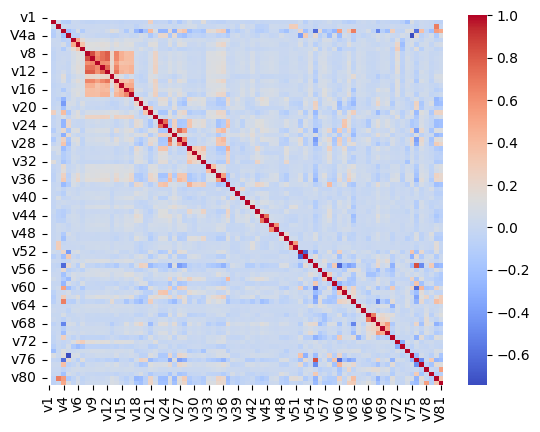

In [ ]:
df_reduced = df[[column for column in df.columns if column not in ['Version','doi']]]
corr_matrix = df_reduced.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")

In [5]:
corr_matrix

NameError: name 'corr_matrix' is not defined

In [ ]:
for column in corr_matrix.columns:
    filtered_df_pos = pd.DataFrame(corr_matrix[corr_matrix[column] > 0.6][column])    
    filtered_df_neg = pd.DataFrame(corr_matrix[corr_matrix[column] < -0.6][column])

    if len(filtered_df_pos) <= 1 and len(filtered_df_neg) <= 1:
        continue
    print(dict_question_code_question[column])
    print('+',[dict_question_code_question[ac] for ac in filtered_df_pos.index])
    print('-',[dict_question_code_question[ac] for ac in filtered_df_neg.index])

    print("----------")

Erhebungsmonat
+ ['Erhebungsmonat', 'Erhebung']
- []
----------
Erhebungsjahr
+ ['Erhebungsjahr', 'Angestrebter Schulabschluss']
- ['Alter in Jahren']
----------
Skalometer: SPD
+ ['Skalometer: SPD', 'Skalometer: CDU', 'Skalometer: CSU', 'Skalometer: FDP', 'Skalometer: Grüne', 'Skalometer: PDS']
- []
----------
Skalometer: CDU
+ ['Skalometer: SPD', 'Skalometer: CDU', 'Skalometer: CSU', 'Skalometer: FDP', 'Skalometer: Grüne', 'Skalometer: PDS']
- []
----------
Skalometer: CSU
+ ['Skalometer: SPD', 'Skalometer: CDU', 'Skalometer: CSU', 'Skalometer: FDP', 'Skalometer: Grüne']
- []
----------
Skalometer: FDP
+ ['Skalometer: SPD', 'Skalometer: CDU', 'Skalometer: CSU', 'Skalometer: FDP', 'Skalometer: Grüne', 'Skalometer: PDS']
- []
----------
Skalometer: Grüne
+ ['Skalometer: SPD', 'Skalometer: CDU', 'Skalometer: CSU', 'Skalometer: FDP', 'Skalometer: Grüne', 'Skalometer: PDS']
- []
----------
Skalometer: PDS
+ ['Skalometer: SPD', 'Skalometer: CDU', 'Skalometer: FDP', 'Skalometer: Grüne', 'Sk

# Clustering

In [9]:
df_reduced = df[['v6','v33']]
df_reduced = df_reduced[df_reduced['v33'] != 0]
df_reduced

,v6,v33
98548,2,1
98549,2,1
98550,3,8
98551,1,14
98552,99,14
...,...,...
1046814,4,999
1046815,4,75
1046816,38,110
1046817,99,75


(0.0, 200.0)

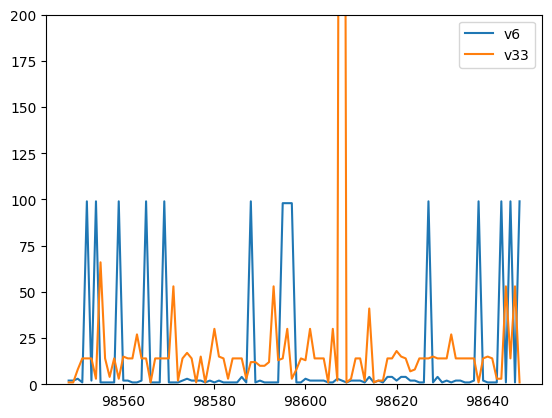

In [13]:
df_reduced[0:100].plot()
plt.ylim(0,200)